In [12]:
# Project outline for Env. Data Sci. Using Initial data to look at any stats or visual patterns across pyrite, grain size, location etc. 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import cartopy as cp
import cartopy.crs as ccrs

#load in file
data = pd.read_csv('Pyrite_mastersheet(raw_data).csv')

# look at data 
print(data.info())
print(data.head())

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sample_ID        205 non-null    str    
 1   Sample_depth_cm  205 non-null    float64
 2   Grain_size_um    151 non-null    float64
 3   Pyrite_wt        162 non-null    float64
 4   Location_name    205 non-null    str    
 5   Lead_210         0 non-null      float64
dtypes: float64(4), str(2)
memory usage: 9.7 KB
None
  Sample_ID  Sample_depth_cm  Grain_size_um  Pyrite_wt Location_name  Lead_210
0     S5S-1              1.0         109.50   4.786370     South_Bay       NaN
1     S5S-2              3.0          69.35   6.301165     South_Bay       NaN
2     S5S-3              5.0          98.60   5.807331     South_Bay       NaN
3     S5S-4              7.0          89.85   6.541926     South_Bay       NaN
4     S5S-5              9.0          80.85   9.283764     South_Bay       NaN


Data collection and information. 
For all of the figures and plots below... 
Pyrite and Grain Size Data: I'm using my own lab measurements for this. I've got pyrite concentrations (showing iron disulfide content) and grain size data (sand, silt, and clay percentages along with mean grain size data) extracted directly from my physical samples using a Mastersizer. 

Sediment Depth and Core Samples: I measured down-core depths relative to the surface. The physical sediment columns themselves come from two methods I used in the field: hand-operated short cores for modern surface layers and vibracores for deeper historical sequences.

Spatial Coverage: My data spans across multiple sampling sites in the Chesapeake Bay, which lets me see how conditions change both locally and across the whole environment. I have a specific focus on different salinities at each site. 

Temporal Coverage: My short cores capture recent, modern sedimentation over decades to a few centuries, while my vibracores reach much deeper into the stratigraphic record to cover a longer-term historical timeline. My goal in this process is to also connect short and vibracore data. 

Overlap: I measured pyrite, grain size, and depth on the exact same sediment slices, meaning I will eventually have matching set of data for every single depth interval in my cores. Because everything lines up, I can directly compare physical changes (like sediment texture) with chemical changes (like pyrite formation) without any mismatch issues (hopefully). 

In [2]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sample_ID        205 non-null    str    
 1   Sample_depth_cm  205 non-null    float64
 2   Grain_size_um    151 non-null    float64
 3   Pyrite_wt        162 non-null    float64
 4   Location_name    205 non-null    str    
 5   Lead_210         0 non-null      float64
dtypes: float64(4), str(2)
memory usage: 13.6 KB


In [3]:
data.shape

(205, 6)

In [4]:
data.size

1230

In [5]:
data.columns

Index(['Sample_ID', 'Sample_depth_cm', 'Grain_size_um', 'Pyrite_wt',
       'Location_name', 'Lead_210'],
      dtype='str')

In [6]:
data.describe()

,Sample_depth_cm,Grain_size_um,Pyrite_wt,Lead_210
count,205.000000,151.000000,162.000000,0.0
mean,24.757073,147.770364,5.380669,NaN
std,26.506357,97.670777,4.264389,NaN
min,1.000000,19.550000,0.269024,NaN
25%,5.000000,70.800000,1.891025,NaN
50%,13.000000,118.000000,4.237580,NaN
75%,32.500000,219.500000,7.620332,NaN
max,112.500000,588.000000,20.002356,NaN


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sample_ID        205 non-null    str    
 1   Sample_depth_cm  205 non-null    float64
 2   Grain_size_um    151 non-null    float64
 3   Pyrite_wt        162 non-null    float64
 4   Location_name    205 non-null    str    
 5   Lead_210         0 non-null      float64
dtypes: float64(4), str(2)
memory usage: 13.6 KB


In [8]:
# double checking if everything looks good
print(data.columns)

Index(['Sample_ID', 'Sample_depth_cm', 'Grain_size_um', 'Pyrite_wt',
       'Location_name', 'Lead_210'],
      dtype='str')


In [11]:
# I am aware there is missing data, but curious to see how many points are missing
missing_counts = data.isnull().sum()
missing_counts[missing_counts >0]

Grain_size_um     54
Pyrite_wt         43
Lead_210         205
dtype: int64

Above the data is showing me that I need to run more grain size and pyrite samples. But these numbers appear to be correct. 

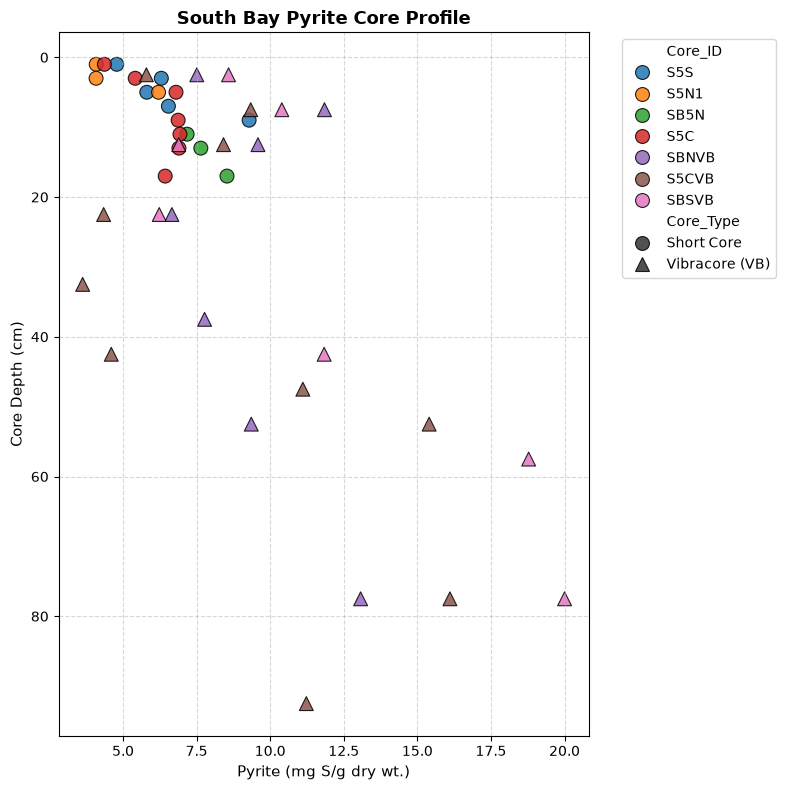

In [4]:
# For this first plot I am plotting a scatter plot with pyrite (mg S/g dry weight sed.) along core depth (cm). 

# Filter for South Bay locations
south_bay = data[data['Location_name'].str.lower().str.contains('south_bay|south bay', na=False)].copy()

# Extract Core ID prefix - used Ai for this
south_bay['Core_ID'] = south_bay['Sample_ID'].str.extract(r'([A-Za-z0-9]+)-')[0]

# Classify cores into 'Vibracore (VB)' or 'Short Core'
south_bay['Core_Type'] = south_bay['Core_ID'].apply(lambda x: 'Vibracore (VB)' if 'VB' in str(x) else 'Short Core')

# Define marker mapping: 'o' for circles, '^' for triangles
markers = {'Short Core': 'o', 'Vibracore (VB)': '^'}

plt.figure(figsize=(8, 8))

sns.scatterplot(
    data=south_bay,
    x='Pyrite_wt',
    y='Sample_depth_cm',
    hue='Core_ID',
    style='Core_Type',
    markers=markers,
    s=100,
    alpha=0.85,
    edgecolor='k')

# Invert Y-axis so surface 0 cm is at the top
plt.gca().invert_yaxis()

plt.title('South Bay Pyrite Core Profile', fontsize=13, fontweight='bold')
plt.xlabel('Pyrite (mg S/g dry wt.)', fontsize=11)
plt.ylabel('Core Depth (cm)', fontsize=11)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Shown above I have a great example of a South Bay sediment core plot. This is showing core depth vs. pyrite values. As the depth increases, the pyrite values do as well. I will end up having a plot for every location with this type of data since this is an important base in my research. I'm zooming in and using different symbols for short cores versus vibracores so I can easily tell the two sampling methods apart. Blowing the figure up gives me enough room to see individual data points clearly without everything clumping together, which helps me catch subtle local trends that a crowded overview would completely hide.

/opt/anaconda3/envs/funtimes/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/funtimes/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/funtimes/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/funtimes/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/funtimes/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/funtimes/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.inte

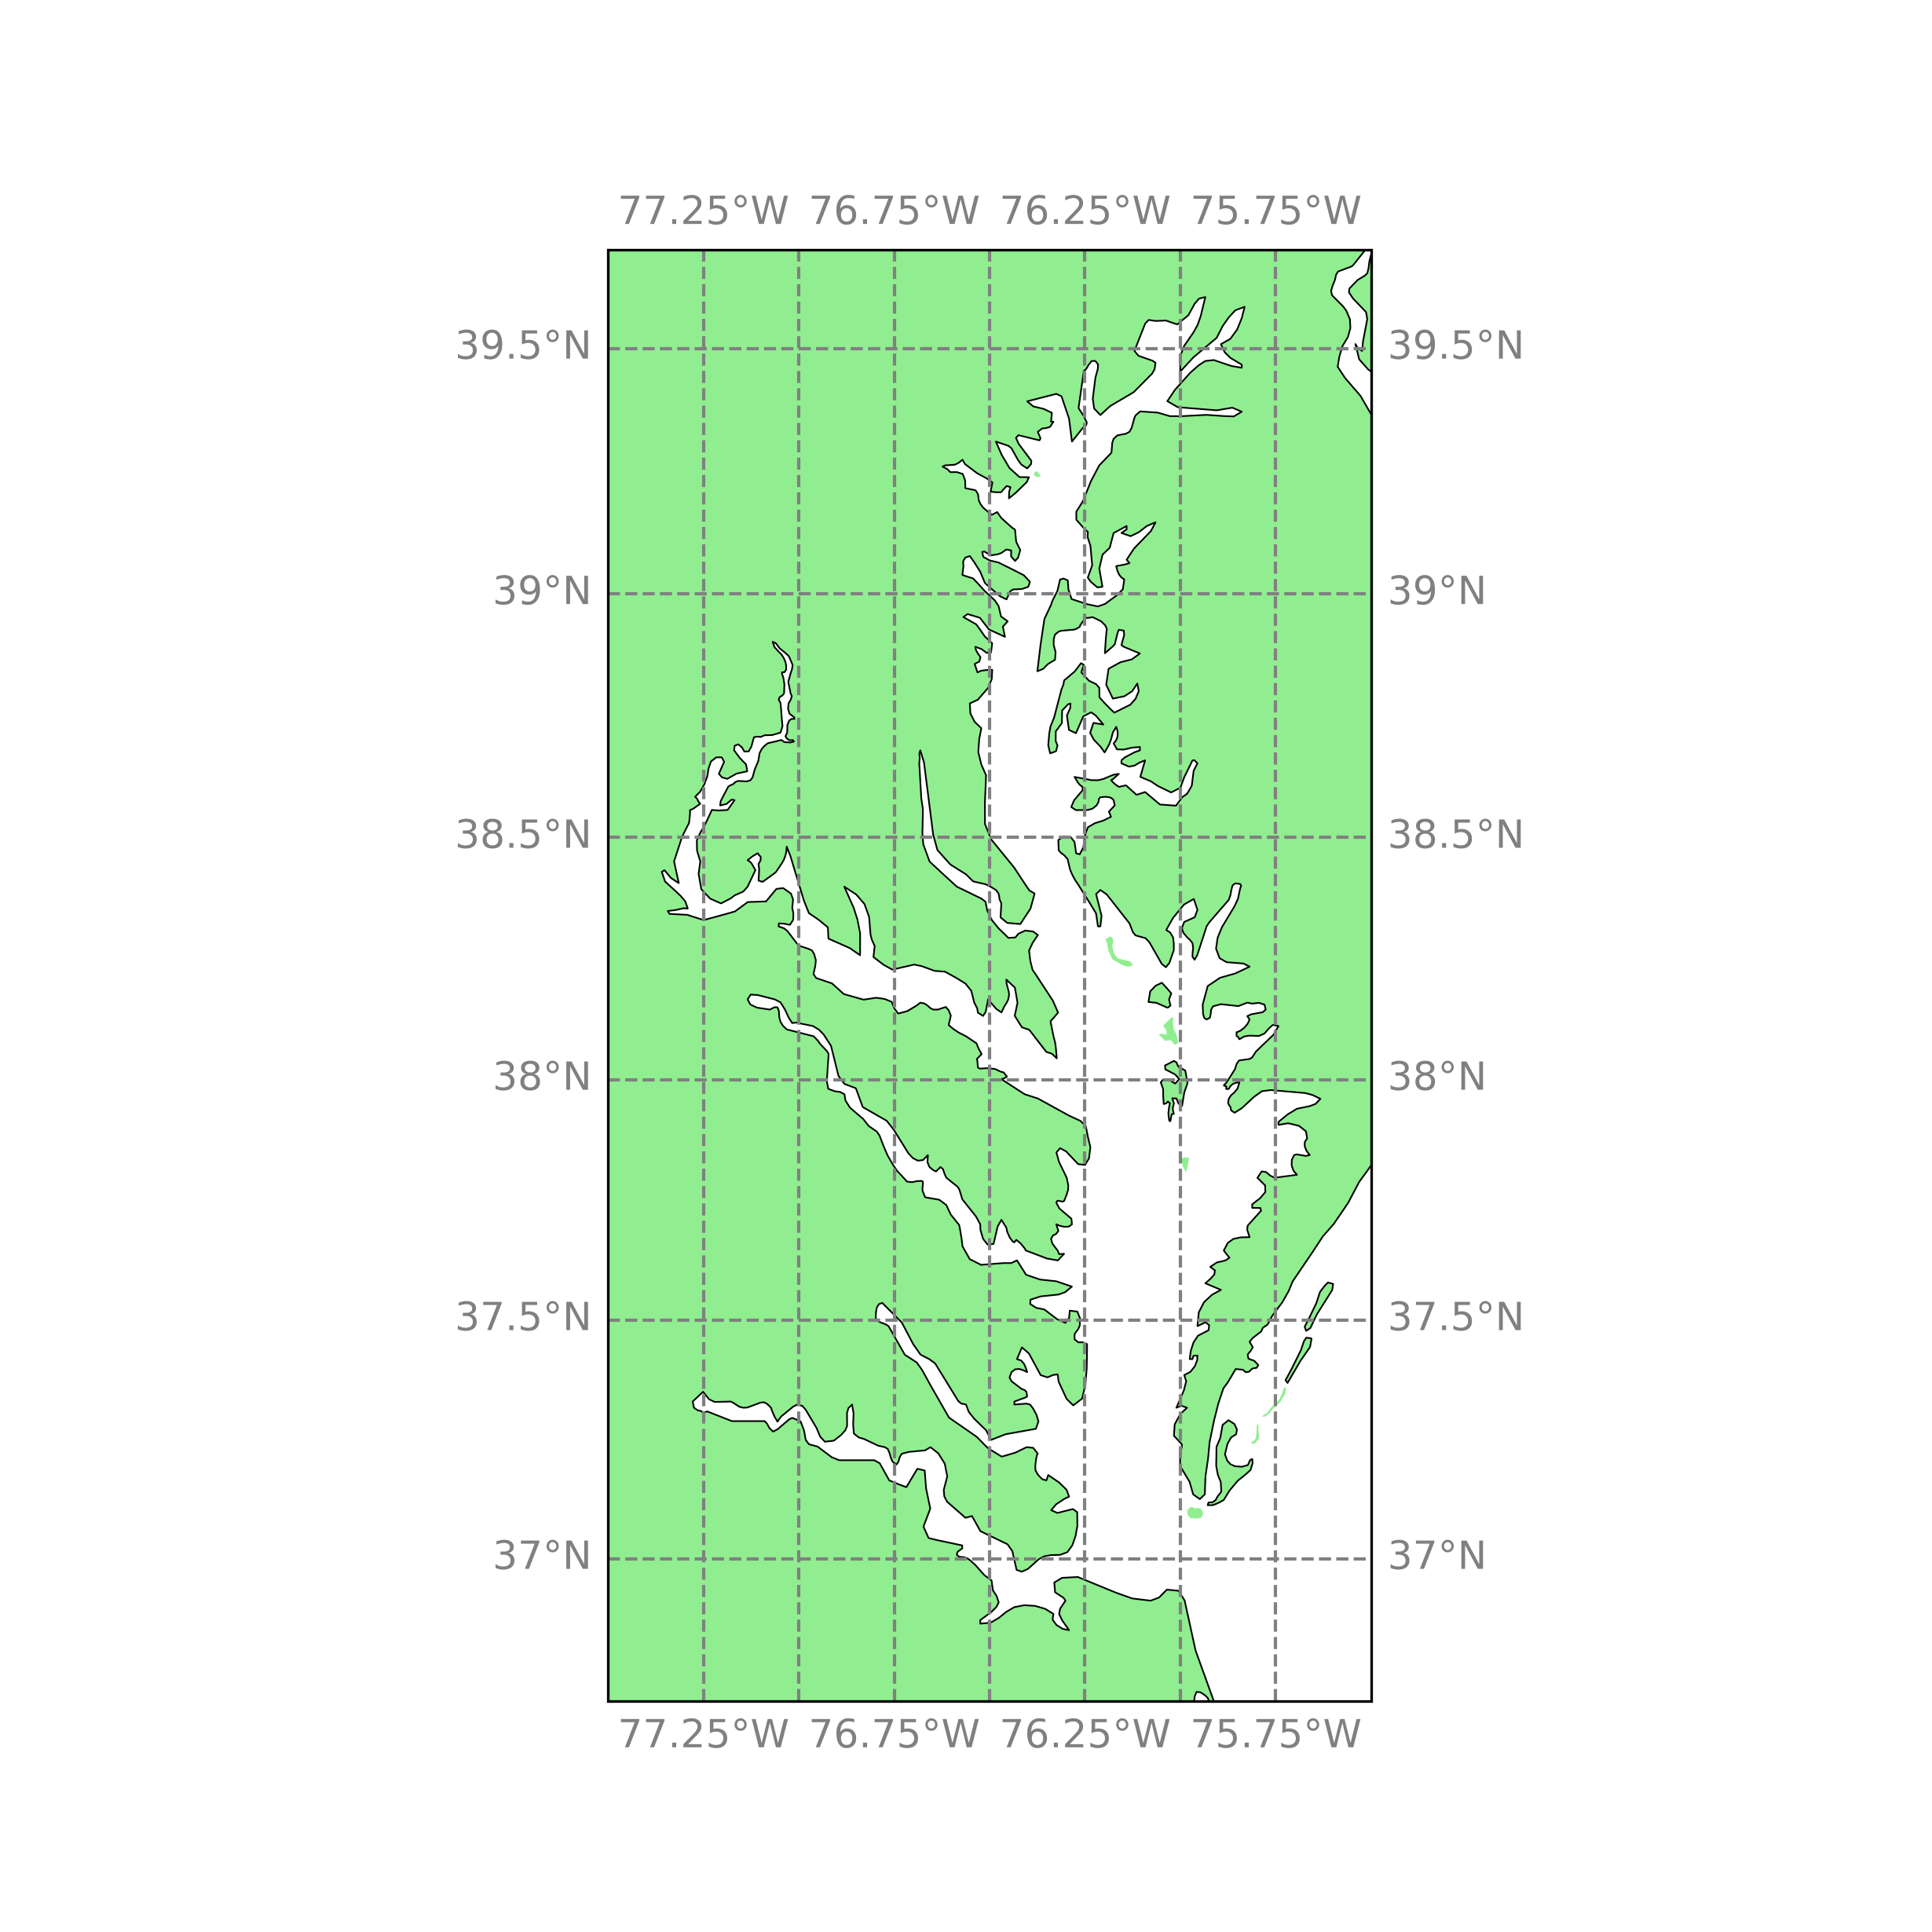

In [19]:
# Making a baseline map for my data using the cartopy example
# Location is the Chesapeake Bay
fig = plt.figure(figsize=(8,8), dpi = 300) 
ax = fig.add_subplot(1,1,1,projection = ccrs.Mercator())

#set axis (E,W,S,N)
ax.set_extent([-75.5, -77.5, 36.7, 39.7])

ax.coastlines(linewidth=0.5, color='black')

ax.set_title('Chesapeake Bay')

import matplotlib.ticker as mticker 
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', linestyle='--')
gl.xlabels_top = False
gl.ylabels_left = True
gl.xlabels_bottom = True
gl.ylabels_right= False

gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

gl.ylocator = mticker.FixedLocator([37.0, 37.5, 38, 38.5, 39, 39.5])

gl.xlabel_style = {'size':12, 'color': 'gray'}
gl.ylabel_style = {'size':12, 'color': 'gray'}

ax.add_feature(cp.feature.LAND, facecolor = 'lightgreen')


Here I used the example from cartopy and tweaked it to be a better fit for my project. For example, I changed the coordinates to show the location of my dataset (along the Chesapeake Bay), changed the map to the color green, changed the font to a light ggray, etc. My end goal with this plot is to show my data sites and their potential salinity values. I do not have the specific coordinates for my core collection since they were done the summer before I got to ODU, but for the final project I plan to gather that data and plot where exactly my cores were taken along the Bay.

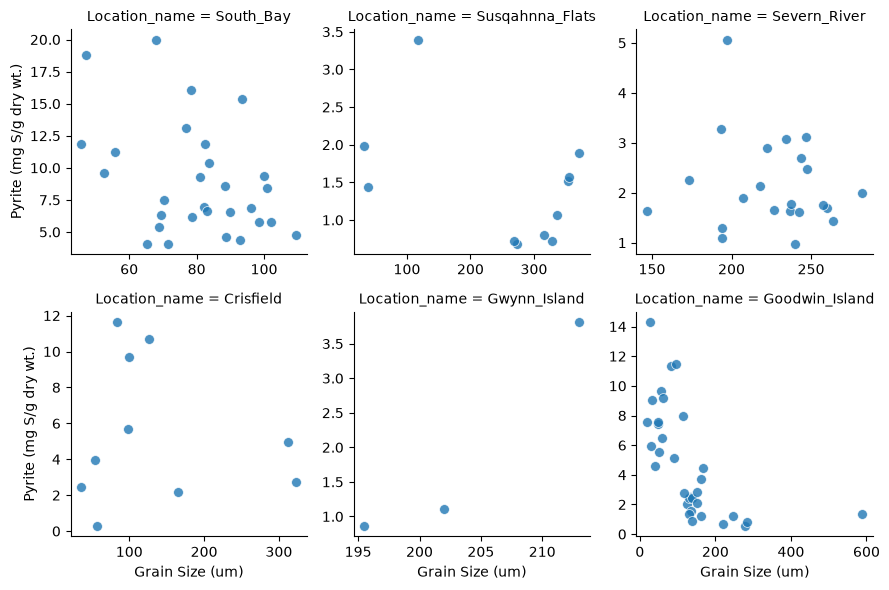

In [24]:

#subplot grid separated by Location
g = sns.FacetGrid(data.dropna(subset=['Grain_size_um', 'Pyrite_wt', 'Location_name']),
    col="Location_name",
    col_wrap=3, sharex= False, sharey= False)

#Map scatter plot onto each location
g.map_dataframe(sns.scatterplot,x="Grain_size_um",y="Pyrite_wt",alpha=0.8,s=50)

# add clean axis labels and display
g.set_axis_labels("Grain Size (um)", "Pyrite (mg S/g dry wt.)")
plt.tight_layout()
plt.show()

With this plot above I am trying to determine if there is any patterns or correlations between grain size and pyrite. There seems to be a negative trend in Goodwin Island but all of the rest seem to be random. This is another important part of my project to see if what we hypothesized with grain size and pyrite hold true (it is looking that it may not in the data). This allows me to immediately see whether higher pyrite concentrations consistently associate with specific sediment textures on a broad scale.

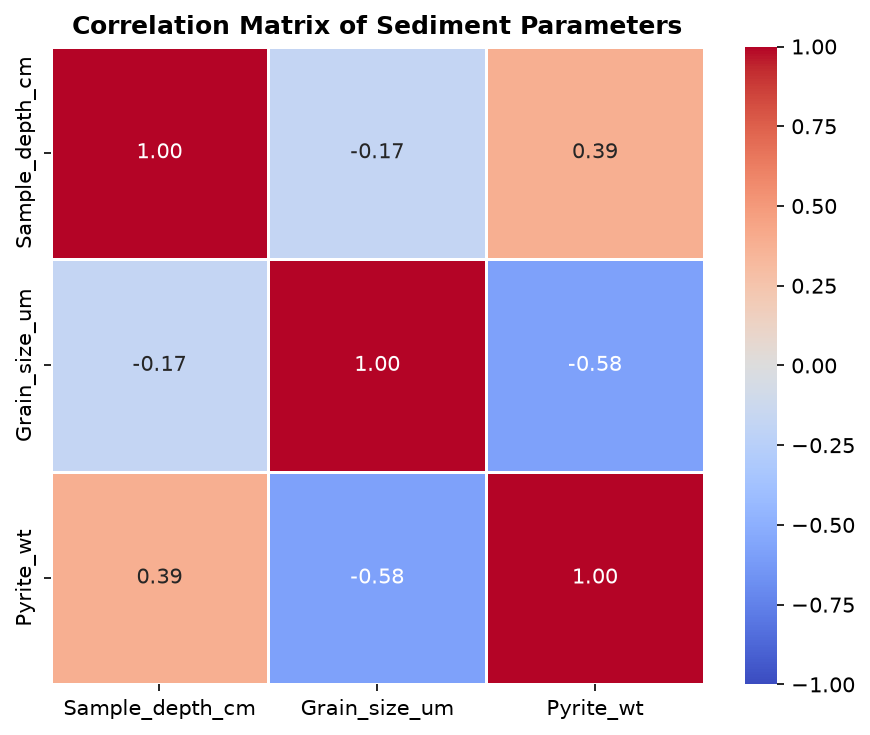

In [27]:

#I will be making a simple correlation matrix plot
numeric_cols = ['Sample_depth_cm', 'Grain_size_um', 'Pyrite_wt']
corr_matrix = data[numeric_cols].corr()

#correlation heatmap
plt.figure(figsize=(6, 5), dpi=150)
sns.heatmap(corr_matrix, 
    annot=True,          # display correlation numbers in each box
    cmap='coolwarm',     # blue = negative correlation, red = positive correlation
    vmin=-1, vmax=1,     #makes scale between -1 and +1
    fmt=".2f",           # Round numbers
    linewidths=0.5)

plt.title('Correlation Matrix of Sediment Parameters', fontweight='bold')
plt.tight_layout()
plt.show()

This is a very simple correlation matrix between all of the locations and data. Pyrite and sample depth seem to have a slight positive correlation while grain size and pyrite seem to have a slight negative correlation. Both of these are expected but to get raaw number values on this data is reassuring. Specifically, this helps me determine if finer sediments concentrate more pyrite that is often by trapping the organic matter needed for its formation and whether burial depth tracks changes in redox conditions. Ultimately, this statistical approach allows me to replace guesswork with concrete evidence when interpreting my data. 

/var/folders/2r/_l_wc55900lb89zkh5bdnt_00000gn/T/ipykernel_48859/1706966128.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data,


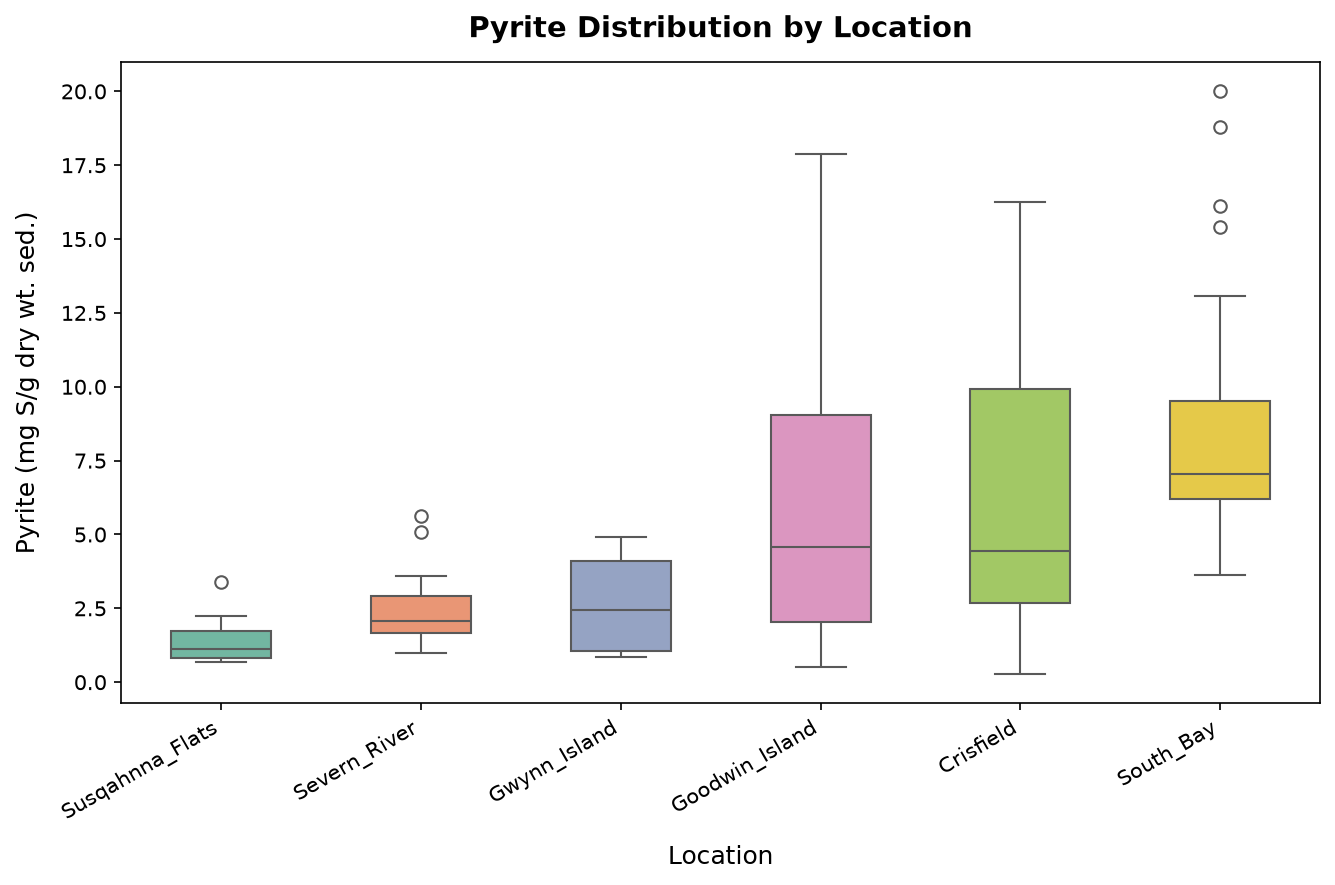

In [45]:
# An important part of this project is to also see how pyrite varies over location (based off salinity)

location_order = ['Susqahnna_Flats', 'Severn_River', 'Gwynn_Island', 'Goodwin_Island', 'Crisfield', 'South_Bay']

plt.figure(figsize=(9, 6), dpi=150)

sns.boxplot(data=data,
    x='Location_name',y='Pyrite_wt',order=location_order, palette='Set2', width=0.5 )
                
# labels
plt.title('Pyrite Distribution by Location', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Location', fontsize=12, labelpad=10)
plt.ylabel('Pyrite (mg S/g dry wt. sed.)', fontsize=12, labelpad=10)
plt.xticks(rotation=30, ha='right', fontsize=10)  # rotates X-axis labels slightly for clean layout

plt.tight_layout()
plt.show()

Above is a beautiful box plot showing average values of pyrite across different locations. I set a specific order to be able to show low salinity to high salinity locations. These values are what I would expect but to visially lay them out like this is easy to ingest. I am using a boxplot for my pyrite data because it allows me to simultaneously compare the central spread and overall distribution of pyrite concentrations across multiple locations at a glance. Additionally, it helps me easily spot any potential outliers or anomalies without letting extreme values distort my visual comparisons between sites.